In [1]:
#mount the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import datetime
from statsmodels.tsa.stattools import coint
from itertools import combinations

In [3]:
Data=pd.read_csv("/content/drive/My Drive/242B Project_LSTM+Sentiment+MAB/Train_Dataset_No_Sentiment.csv",header=None)

raw=Data.copy()
# Row 0 = tickers, row 1 = price fields
tickers = raw.iloc[0]
fields = raw.iloc[1]

# Actual data starts at row 3, skipping the 'Date' header row which was read as data
df = raw.iloc[3:].copy()

# First column is Date
df = df.rename(columns={0: "Date"})
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

# Build MultiIndex columns: (ticker, field)
new_cols = []
for ticker, field in zip(tickers[1:], fields[1:]):
    new_cols.append((ticker, field.lower()))

df.columns = pd.MultiIndex.from_tuples(new_cols, names=["ticker", "field"])

# Convert values to numeric
df = df.apply(pd.to_numeric)
df.head()

ticker            APA                                                   COP  \
field           close       high        low       open    volume      close   
Date                                                                          
2022-01-03  24.343285  24.412688  23.406337  23.493092   9319700  63.208145   
2022-01-04  25.557844  25.974267  24.811757  24.898512  13218200  65.949982   
2022-01-05  24.638248  26.104398  24.612223  26.026319   9212700  64.818977   
2022-01-06  25.696651  25.948238  24.967914  25.471090   7626800  67.252373   
2022-01-07  25.740030  26.286582  25.523144  25.896188   8355400  69.094551   

ticker                                                 ...        VLO  \
field            high        low       open    volume  ...      close   
Date                                                   ...              
2022-01-03  63.370944  61.708697  61.717268   5769900  ...  67.498604   
2022-01-04  66.301277  63.645115  63.885025   9189300  ...  68.697388   
2022-01-05  67.063860  64.707586  66.815386   9034500  ...  68.426109   
2022-01-06  67.509424  65.890020  66.678300   8679000  ...  70.141151   
2022-01-07  69.343032  67.158120  67.577970  10838800  ...  70.876160   

ticker                                                      XOM             \
field            high        low       open   volume      close       high   
Date                                                                         
2022-01-03  68.434869  66.124832  66.326088  3568200  54.760239  54.811946   
2022-01-04  69.467398  68.137379  68.399879  4171700  56.819996  57.044072   
2022-01-05  69.861132  68.111104  69.344877  3999800  57.526684  58.267852   
2022-01-06  70.412404  69.091130  70.001146  4248200  58.879753  59.017648   
2022-01-07  71.252416  69.957392  70.508655  3723200  59.362370  59.620919   

ticker                                      
field             low       open    volume  
Date                                        
2022-01-03  52.752189  52.778046  24282400  
2022-01-04  55.242858  55.268712  38584000  
2022-01-05  57.293994  57.311228  34033300  
2022-01-06  57.802474  58.603970  30668500  
2022-01-07  58.586734  59.052113  23985400  

[5 rows x 70 columns]

In [4]:

def compute_metrics(strategy_returns, periods_per_year=252):
    r = strategy_returns.dropna()

    if len(r) == 0:
        return {
            "Cumulative Return": np.nan,
            "Annualized Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown": np.nan,
            "Win Rate": np.nan,
        }

    cumulative_curve = (1 + r).cumprod()

    cumulative_return = cumulative_curve.iloc[-1] - 1

    annualized_volatility = r.std() * np.sqrt(periods_per_year)

    if r.std() == 0:
        sharpe = np.nan
    else:
        sharpe = (r.mean() / r.std()) * np.sqrt(periods_per_year)

    peak = cumulative_curve.cummax()
    drawdown = (cumulative_curve - peak) / peak
    max_drawdown = drawdown.min()

    win_rate = (r > 0).mean()

    return {
        "Cumulative Return": cumulative_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown,
        "Win Rate": win_rate,
    }

In [5]:
tickers = [
    "XOM",
    "CVX",
    "COP",
    "OXY",
   # "PXD":  "Pioneer Natural Resources",
    "SLB",
    "HAL",
    "EOG",
    "DVN",
    "MPC",

    # stocks added by Ryan

    #"PLC": "Principal U.S. Large-Cap Multi-Factor ETF",
    "FANG",
    "PSX",
    "VLO",
    "CTRA",
    "APA"
]

## Single Stock Evaluation

### Momentum (20 day lookback)

In [6]:

def time_series_momentum_strategy(Data_Frame, stock_name,start_date, end_date,price_col="close", lookback=20, threshold=0.0, allow_short=True):
    # Filter for the specific stock
    stock_df = Data_Frame[stock_name].copy()

    #start from the first available date
    # on or after start_date, handling non-trading days.
    out = stock_df.loc[start_date:].copy()

    out["return"] = out[price_col].pct_change() # return for each day (rate of change)
    out["momentum"] = out[price_col].pct_change(lookback) # return for 20 days lookback

    if allow_short:
        out["signal"] = np.select(
            [out["momentum"] > threshold, out["momentum"] < -threshold],
            [1, -1],
            default=0
        )
    else:
        out["signal"] = np.where(out["momentum"] > threshold, 1, 0)

    out["position"] = out["signal"].shift(1).fillna(0)

    out["trade"] = out["position"].diff().abs().fillna(0)
    out["strategy_return"] = out["position"] * out["return"]

    out["cumulative_strategy_return"] = (1 + out["strategy_return"].fillna(0)).cumprod()
    out["cumulative_asset_return"] = (1 + out["return"].fillna(0)).cumprod()

    # Slice after features are computed
    if start_date is not None:
        out = out.loc[start_date:]
    if end_date is not None:
        out = out.loc[:end_date]

    return out

In [7]:
result_mm = time_series_momentum_strategy(
    df,
    "APA",
    start_date="2022-01-03",
    end_date="2023-01-03",
    price_col="close",
    lookback=20,
    threshold=0.02,
    allow_short=True
)

print(result_mm['position'].loc["2026-02-01":"2026-04-10"])

Series([], Name: position, dtype: float64)


In [8]:
metrics = compute_metrics(result_mm["strategy_return"])

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Cumulative Return: -0.6122
Annualized Volatility: 0.5406
Sharpe Ratio: -1.4832
Max Drawdown: -0.6367
Win Rate: 0.3745


## Mean Reversion

In [9]:
import numpy as np
import pandas as pd

def mean_reversion_strategy(
    Data_Frame,
    stock_name,
    price_col="Close",
    lookback=20,
    entry_z=2.0,
    exit_z=0.5,
    allow_short=True,
    start_date=None,
    end_date=None
):
    stock_df = Data_Frame[stock_name].copy()

    #start from the first available date
    # on or after start_date, handling non-trading days.
    out = stock_df.loc[start_date:].copy()

    # 1-period asset return
    out["return"] = out[price_col].pct_change()

    # Rolling mean and std = estimate of "normal" price behavior
    out["rolling_mean"] = out[price_col].rolling(window=lookback).mean()
    out["rolling_std"] = out[price_col].rolling(window=lookback).std()

    # Z-score: how far price is from its recent average
    out["z_score"] = (out[price_col] - out["rolling_mean"]) / out["rolling_std"]

    # Start flat
    out["signal"] = 0

    if allow_short:
        # Price too low relative to average → long
        out.loc[out["z_score"] < -entry_z, "signal"] = 1

        # Price too high relative to average → short
        out.loc[out["z_score"] > entry_z, "signal"] = -1
    else:
        # Long-only version
        out.loc[out["z_score"] < -entry_z, "signal"] = 1

    # Exit when price comes back close to average
    out.loc[out["z_score"].abs() < exit_z, "signal"] = 0

    # Carry position forward until new signal or exit
    out["position"] = out["signal"].replace(0, np.nan).ffill().fillna(0)

    # If exit condition is met, force position to 0
    out.loc[out["z_score"].abs() < exit_z, "position"] = 0

    # Shift position to avoid lookahead bias
    out["position"] = out["position"].shift(1).fillna(0)

    # Trade size/change
    out["trade"] = out["position"].diff().abs().fillna(0)

    # Strategy return
    out["strategy_return"] = out["position"] * out["return"]

    # Cumulative performance
    out["cumulative_strategy_return"] = (1 + out["strategy_return"].fillna(0)).cumprod()
    out["cumulative_asset_return"] = (1 + out["return"].fillna(0)).cumprod()

    # Slice after features are computed
    if start_date is not None:
        out = out.loc[start_date:]
    if end_date is not None:
        out = out.loc[:end_date]

    return out

In [10]:
result_mr = mean_reversion_strategy(
    df,
    "APA",
    price_col="close",
    lookback=20,
    entry_z=2.0,
    exit_z=0.5,
    allow_short=True,
    start_date="2022-01-03",
    end_date="2023-01-03"
)

result_mr[[
    "close",
    "rolling_mean",
    "z_score",
    "signal",
    "position",
    "strategy_return"
]].tail()

field,close,rolling_mean,z_score,signal,position,strategy_return
Date,,,,,,
2022-12-27,42.006996,39.810534,1.510230,0,1.0,0.008254
2022-12-28,39.837872,39.748370,0.062876,0,1.0,-0.051637
2022-12-29,40.481552,39.706928,0.558410,0,0.0,0.000000
2022-12-30,41.160515,39.705164,1.050624,0,1.0,0.016772
2023-01-03,38.462322,39.551297,-0.812103,0,1.0,-0.065553


In [11]:
metrics_mr = compute_metrics(result_mr["strategy_return"])

for k, v in metrics_mr.items():
    print(f"{k}: {v:.4f}")

Cumulative Return: 0.4947
Annualized Volatility: 0.4802
Sharpe Ratio: 1.0818
Max Drawdown: -0.3654
Win Rate: 0.3625


### Closing Range Breakout

In [12]:

def closing_range_breakout(
    Data_Frame,
    stock_name,
    price_col="close",
    lookback=20,
    upper_th=0.8,
    lower_th=0.2,
    allow_short=True,
    start_date=None,
    end_date=None
):
    stock_df = Data_Frame[stock_name].copy()

    #start from the first available date
    # on or after start_date, handling non-trading days.
    out = stock_df.loc[start_date:].copy()

    # Returns
    out["return"] = out[price_col].pct_change()

    # Rolling high and low
    out["rolling_high"] = out[price_col].rolling(lookback).max()
    out["rolling_low"]  = out[price_col].rolling(lookback).min()

    # Closing range
    out["cr"] = (out[price_col] - out["rolling_low"]) / (
        out["rolling_high"] - out["rolling_low"]
    )

    # Signal
    if allow_short:
        out["signal"] = np.select(
            [out["cr"] > upper_th, out["cr"] < lower_th],
            [1, -1],
            default=0
        )
    else:
        out["signal"] = np.where(out["cr"] > upper_th, 1, 0)

    # Position (avoid lookahead bias)
    out["position"] = out["signal"].shift(1).fillna(0)

    # Strategy return
    out["strategy_return"] = out["position"] * out["return"]

    # Cumulative returns
    out["cumulative_strategy_return"] = (1 + out["strategy_return"].fillna(0)).cumprod()
    out["cumulative_asset_return"] = (1 + out["return"].fillna(0)).cumprod()

    # Slice after computing features
    if start_date is not None:
        out = out.loc[start_date:]
    if end_date is not None:
        out = out.loc[:end_date]

    return out

In [13]:
result_crb = closing_range_breakout(
    df,
    "APA",
    price_col="close",
    lookback=20,
    upper_th=0.8,
    lower_th=0.2,
    allow_short=True,
    start_date="2022-01-03",
    end_date="2023-01-03"
)

result_crb[[
    "close",
    "rolling_high",
    "rolling_low",
    "cr",
    "signal",
    "position",
    "strategy_return",
    "cumulative_strategy_return"
]].head(40)


field,close,rolling_high,rolling_low,cr,signal,position,strategy_return,cumulative_strategy_return
Date,,,,,,,,
2022-01-03,24.343285,NaN,NaN,NaN,0,0.0,NaN,1.000000
2022-01-04,25.557844,NaN,NaN,NaN,0,0.0,0.000000,1.000000
2022-01-05,24.638248,NaN,NaN,NaN,0,0.0,-0.000000,1.000000
2022-01-06,25.696651,NaN,NaN,NaN,0,0.0,0.000000,1.000000
2022-01-07,25.740030,NaN,NaN,NaN,0,0.0,0.000000,1.000000
2022-01-10,25.523146,NaN,NaN,NaN,0,0.0,-0.000000,1.000000
2022-01-11,27.761408,NaN,NaN,NaN,0,0.0,0.000000,1.000000
2022-01-12,28.325312,NaN,NaN,NaN,0,0.0,0.000000,1.000000
2022-01-13,27.839487,NaN,NaN,NaN,0,0.0,-0.000000,1.000000


In [14]:
metrics_crb = compute_metrics(result_crb["strategy_return"])

for k, v in metrics_crb.items():
    print(f"{k}: {v:.4f}")

Cumulative Return: -0.4144
Annualized Volatility: 0.4332
Sharpe Ratio: -1.0202
Max Drawdown: -0.4407
Win Rate: 0.2669


### Turnaround Tueasday - IBS (Internal Bar Strength)

In [15]:
def turnaround_tuesday_ibs(
    Data_Frame,
    stock_name,
    ibs_threshold=0.2,
    start_date=None,
    end_date=None
):
    stock_df = Data_Frame[stock_name].copy()

    #start from the first available date
    # on or after start_date, handling non-trading days.
    out = stock_df.loc[start_date:].copy()

    # Returns
    out["return"] = out["close"].pct_change()

    # IBS
    out["ibs"] = (out["close"] - out["low"]) / (out["high"] - out["low"])

    # Day of week (Monday = 0, Tuesday = 1, ...)
    out["weekday"] = pd.to_datetime(out.index).weekday

    # Initialize position
    out["position"] = 0

    # Entry: Monday IBS signal → position on Tuesday
    entry_signal = (out["weekday"] == 0) & (out["ibs"] < ibs_threshold)

    # Shift to enter on Tuesday
    out.loc[entry_signal.shift(1, fill_value=False), "position"] = 1

    # Exit after 1 day → automatically handled since no carry forward

    # Strategy return
    out["strategy_return"] = out["position"] * out["return"]

    # Cumulative returns
    out["cumulative_strategy_return"] = (1 + out["strategy_return"].fillna(0)).cumprod()
    out["cumulative_asset_return"] = (1 + out["return"].fillna(0)).cumprod()

    # Slice
    if start_date is not None:
        out = out.loc[start_date:]
    if end_date is not None:
        out = out.loc[:end_date]

    return out

In [16]:
result_ibs = turnaround_tuesday_ibs(
    df,
    "APA",
    ibs_threshold=0.2,
    start_date="2022-01-03",
    end_date="2023-01-03"
)

result_ibs[result_ibs["position"]!=0]

field,close,high,low,open,volume,return,ibs,weekday,position,strategy_return,cumulative_strategy_return,cumulative_asset_return
Date,,,,,,,,,,,,
2022-02-15,28.069305,28.199943,26.911000,27.041636,6883700,0.002800,0.898648,1,1,0.002800,1.002800,1.153062
2022-03-08,33.643108,35.881337,32.624146,34.078561,16485200,0.018724,0.312835,1,1,0.018724,1.021577,1.382028
2022-04-12,36.734810,37.675386,36.534502,36.560628,5817500,0.027027,0.175572,1,1,0.027027,1.049187,1.509033
2022-05-10,32.646526,34.480599,31.546080,33.371421,11971800,-0.003997,0.375001,1,1,-0.003997,1.044993,1.341090
2022-09-27,28.643990,29.283833,28.030440,28.775466,10516700,0.026382,0.489511,1,1,0.026382,1.072562,1.176669
2022-10-11,35.480682,36.409773,34.937254,35.147612,7325300,-0.016760,0.369047,1,1,-0.016760,1.054586,1.457514
2022-10-18,34.902199,35.892644,34.157176,35.366742,7240600,-0.006982,0.429292,1,1,-0.006982,1.047223,1.433751
2022-11-15,43.241467,43.400183,41.028249,41.839469,5814400,0.038763,0.933085,1,1,0.038763,1.087816,1.776320
2022-12-06,38.682758,40.737258,38.427051,39.732053,5685200,-0.040254,0.110686,1,1,-0.040254,1.044028,1.589053


In [17]:
metrics_ibs = compute_metrics(result_ibs["strategy_return"])

for k, v in metrics_ibs.items():
    print(f"{k}: {v:.4f}")

Cumulative Return: 0.0440
Annualized Volatility: 0.0727
Sharpe Ratio: 0.6311
Max Drawdown: -0.0403
Win Rate: 0.0199


### ATR (Average True Value) Breakout

In [18]:

def atr_breakout(
    Data_Frame,
    stock_name,
    high_col="high",
    low_col="low",
    close_col="close",
    atr_lookback=14,
    multiplier=2.0,
    allow_short=True,
    start_date=None,
    end_date=None
):
    stock_df = Data_Frame[stock_name].copy()

    #start from the first available date
    # on or after start_date, handling non-trading days.
    out = stock_df.loc[start_date:].copy()

    # Returns
    out["return"] = out[close_col].pct_change()

    # True Range
    out["tr"] = np.maximum.reduce([
        out[high_col] - out[low_col],
        (out[high_col] - out[close_col].shift(1)).abs(),
        (out[low_col] - out[close_col].shift(1)).abs()
    ])

    # ATR
    out["atr"] = out["tr"].rolling(atr_lookback).mean()

    # Breakout levels (use previous values to avoid lookahead bias)
    out["upper"] = out[close_col].shift(1) + multiplier * out["atr"].shift(1)
    out["lower"] = out[close_col].shift(1) - multiplier * out["atr"].shift(1)

    # Signal
    if allow_short:
        out["signal"] = np.select(
            [out[close_col] > out["upper"], out[close_col] < out["lower"]],
            [1, -1],
            default=0
        )
    else:
        out["signal"] = np.where(out[close_col] > out["upper"], 1, 0)

    # Position
    out["position"] = out["signal"].shift(1).fillna(0)

    # Strategy return
    out["strategy_return"] = out["position"] * out["return"]

    # Cumulative returns
    out["cumulative_strategy_return"] = (1 + out["strategy_return"].fillna(0)).cumprod()
    out["cumulative_asset_return"] = (1 + out["return"].fillna(0)).cumprod()

    # Slice
    if start_date is not None:
        out = out.loc[start_date:]
    if end_date is not None:
        out = out.loc[:end_date]

    return out

In [19]:
result_atr = atr_breakout(
    df,
    "APA",
    high_col="high",
    low_col="low",
    close_col="close",
    atr_lookback=14,
    multiplier=2.0,
    allow_short=True,
    start_date="2022-01-03",
    end_date="2023-01-03"
)


result_atr[["close","tr","atr","upper","lower","signal","position","strategy_return","cumulative_strategy_return", "cumulative_asset_return"]].tail()


field,close,tr,atr,upper,lower,signal,position,strategy_return,cumulative_strategy_return,cumulative_asset_return
Date,,,,,,,,,,
2022-12-27,42.006996,0.784771,1.795639,45.472302,37.853908,0,0.0,0.0,1.035458,1.725609
2022-12-28,39.837872,2.292570,1.867439,45.598274,38.415719,0,0.0,-0.0,1.035458,1.636504
2022-12-29,40.481552,1.640072,1.816423,43.572749,36.102994,0,0.0,0.0,1.035458,1.662945
2022-12-30,41.160515,1.119834,1.783042,44.114398,36.848707,0,0.0,0.0,1.035458,1.690837
2023-01-03,38.462322,3.227247,1.856102,44.726598,37.594431,0,0.0,-0.0,1.035458,1.579997


In [20]:
metrics_atr = compute_metrics(result_atr["strategy_return"])

for k, v in metrics_atr.items():
    print(f"{k}: {v:.4f}")

Cumulative Return: 0.0355
Annualized Volatility: 0.0316
Sharpe Ratio: 1.1213
Max Drawdown: 0.0000
Win Rate: 0.0080


### Pairs Trading

In [21]:

def pairs_trading(
    Data_Frame,
    tickers,
    close_col="close",
    lookback=60,
    z_entry=2.0,
    z_exit=0.5,
    start_date=None,
    end_date=None
):
    df = Data_Frame.copy()

    # Select only the 'close' price for the specified tickers
    # Use .loc with a MultiIndex slice to get the correct columns
    prices = df.loc[:, (tickers, close_col)].copy()

    # Rename columns to just the ticker names for easier access later
    # The columns are now (ticker, close_col), we want just ticker
    prices.columns = prices.columns.get_level_values(0)

    # Slice by date
    if start_date is not None:
        prices = prices.loc[start_date:]
    if end_date is not None:
        prices = prices.loc[:end_date]

    # Drop tickers with too many missing values
    prices = prices.dropna(axis=1)

    # Need at least 2 stocks
    if prices.shape[1] < 2:
        raise ValueError("Need at least two valid tickers with price data.")

    # --------------------------------------------------
    # 1. Choose best pair using cointegration test
    # --------------------------------------------------

    best_pair = None
    best_pvalue = np.inf

    for stock_a, stock_b in combinations(prices.columns, 2):
        series_a = prices[stock_a].dropna()
        series_b = prices[stock_b].dropna()

        common_index = series_a.index.intersection(series_b.index)
        series_a = series_a.loc[common_index]
        series_b = series_b.loc[common_index]

        if len(series_a) < lookback:
            continue

        score, pvalue, _ = coint(series_a, series_b)

        if pvalue < best_pvalue:
            best_pvalue = pvalue
            best_pair = (stock_a, stock_b)

    if best_pair is None:
        raise ValueError("No valid pair found.")

    stock_a, stock_b = best_pair

    # --------------------------------------------------
    # 2. Run pairs trading on selected pair
    # --------------------------------------------------

    out = prices[[stock_a, stock_b]].dropna().copy()

    out["log_A"] = np.log(out[stock_a])
    out["log_B"] = np.log(out[stock_b])

    # Estimate hedge ratio: log_A = alpha + beta * log_B
    X = sm.add_constant(out["log_B"])
    model = sm.OLS(out["log_A"], X).fit()
    beta = model.params["log_B"]

    # Spread
    out["spread"] = out["log_A"] - beta * out["log_B"]

    # Rolling mean/std of spread
    out["spread_mean"] = out["spread"].rolling(lookback).mean()
    out["spread_std"] = out["spread"].rolling(lookback).std()

    # Z-score
    out["z_score"] = (out["spread"] - out["spread_mean"]) / out["spread_std"]

    # Signal:
    # +1 = long spread = long A, short B
    # -1 = short spread = short A, long B
    out["signal"] = 0
    out.loc[out["z_score"] < -z_entry, "signal"] = 1
    out.loc[out["z_score"] > z_entry, "signal"] = -1

    # Exit when spread comes back near mean
    out.loc[out["z_score"].abs() < z_exit, "signal"] = 0

    # Stateful position
    out["position"] = out["signal"].replace(0, np.nan).ffill().fillna(0)

    # Force exit when z-score is close to 0
    out.loc[out["z_score"].abs() < z_exit, "position"] = 0

    # Shift to avoid lookahead bias
    out["position"] = out["position"].shift(1).fillna(0)

    # Returns
    out["ret_A"] = out[stock_a].pct_change()
    out["ret_B"] = out[stock_b].pct_change()

    # Strategy return
    out["strategy_return"] = out["position"] * (out["ret_A"] - beta * out["ret_B"])

    # Cumulative return
    out["cumulative_strategy_return"] = (
        1 + out["strategy_return"].fillna(0)
    ).cumprod()

    # Useful metadata columns
    out["stock_A"] = stock_a
    out["stock_B"] = stock_b
    out["beta"] = beta
    out["cointegration_pvalue"] = best_pvalue

    return out

In [22]:
result_pt = pairs_trading(
    df,
    tickers,
    close_col="close",
    lookback=20,
    z_entry=2.0,
    z_exit=0.5,
    start_date="2022-01-03",
    end_date="2023-01-03"
)

# Dynamically get the chosen stock names from the result_pt DataFrame
stock_a = result_pt['stock_A'].iloc[0]
stock_b = result_pt['stock_B'].iloc[0]

# Display relevant columns generated by the pairs_trading function, using dynamic stock names
result_pt[[stock_a, stock_b, "spread", "z_score", "signal", "position", "strategy_return", "cumulative_strategy_return"]].tail()

ticker,XOM,MPC,spread,z_score,signal,position,strategy_return,cumulative_strategy_return
Date,,,,,,,,
2022-12-27,98.731544,108.886047,0.751010,0.342105,0,0.0,0.00000,1.237231
2022-12-28,97.109734,106.742249,0.750733,0.217262,0,0.0,-0.00000,1.237231
2022-12-29,97.844467,108.289520,0.746484,-0.455364,0,0.0,-0.00000,1.237231
2022-12-30,98.830093,108.485268,0.755028,0.674040,0,0.0,0.00000,1.237231
2023-01-03,95.434196,103.386749,0.759488,1.332928,0,1.0,0.00413,1.242341


In [23]:
metrics_pt = compute_metrics(result_pt["strategy_return"])

for k, v in metrics_pt.items():
    print(f"{k}: {v:.4f}")

Cumulative Return: 0.2423
Annualized Volatility: 0.1913
Sharpe Ratio: 1.2347
Max Drawdown: -0.1301
Win Rate: 0.3267


### Volatility Expension

In [24]:
def volatility_expansion(
    Data_Frame,
    stock_name,
    close_col="close",
    vol_lookback=20,
    vol_multiplier=1.5,
    allow_short=True,
    start_date=None,
    end_date=None
):
    out = Data_Frame[stock_name].copy()

    # Slice
    if start_date is not None:
        out = out.loc[start_date:]
    if end_date is not None:
        out = out.loc[:end_date]

    # Returns
    out["return"] = out[close_col].pct_change()

    # Volatility
    out["vol"] = out["return"].rolling(vol_lookback).std()

    # Previous volatility (baseline)
    out["vol_prev"] = out["vol"].rolling(vol_lookback).mean()

    # Signal
    out["signal"] = 0

    # Volatility expansion condition
    vol_expansion = out["vol"] > vol_multiplier * out["vol_prev"]

    if allow_short:
        out.loc[vol_expansion & (out["return"] > 0), "signal"] = 1
        out.loc[vol_expansion & (out["return"] < 0), "signal"] = -1
    else:
        out.loc[vol_expansion & (out["return"] > 0), "signal"] = 1

    # Position
    out["position"] = out["signal"].shift(1).fillna(0)

    # Strategy return
    out["strategy_return"] = out["position"] * out["return"]

    # Cumulative
    out["cumulative_strategy_return"] = (
        1 + out["strategy_return"].fillna(0)
    ).cumprod()

    out["cumulative_asset_return"] = (
        1 + out["return"].fillna(0)
    ).cumprod()

    return out

In [25]:
result_ve = volatility_expansion(
    df,
    "APA",
    close_col="close",
    vol_lookback=20,
    vol_multiplier=1.5,
    allow_short=True,
    start_date="2022-01-03",
    end_date="2023-01-03"
    )

result_ve[["close","vol","vol_prev","signal","position","strategy_return","cumulative_strategy_return", "cumulative_asset_return"]].tail()

field,close,vol,vol_prev,signal,position,strategy_return,cumulative_strategy_return,cumulative_asset_return
Date,,,,,,,,
2022-12-27,42.006996,0.031195,0.030650,0,0.0,0.0,1.002157,1.725609
2022-12-28,39.837872,0.032481,0.030456,0,0.0,-0.0,1.002157,1.636504
2022-12-29,40.481552,0.032680,0.030272,0,0.0,0.0,1.002157,1.662945
2022-12-30,41.160515,0.032900,0.030147,0,0.0,0.0,1.002157,1.690837
2023-01-03,38.462322,0.035975,0.030350,0,0.0,-0.0,1.002157,1.579997


In [26]:
metrics_ve = compute_metrics(result_ve["strategy_return"])

for k, v in metrics_ve.items():
    print(f"{k}: {v:.4f}")

Cumulative Return: 0.0022
Annualized Volatility: 0.0403
Sharpe Ratio: 0.0737
Max Drawdown: -0.0315
Win Rate: 0.0080


### Moving Average Crossover

In [27]:
def moving_average_crossover(
    Data_Frame,
    stock_name,
    close_col="close",
    short_window=20,
    long_window=50,
    allow_short=True,
    start_date=None,
    end_date=None
):
    out = Data_Frame[stock_name].copy()

    # Slice
    if start_date is not None:
        out = out.loc[start_date:]
    if end_date is not None:
        out = out.loc[:end_date]

    # Returns
    out["return"] = out[close_col].pct_change()

    # Moving averages
    out["ma_short"] = out[close_col].rolling(short_window).mean()
    out["ma_long"] = out[close_col].rolling(long_window).mean()

    # Signal
    if allow_short:
        out["signal"] = np.where(
            out["ma_short"] > out["ma_long"], 1, -1
        )
    else:
        out["signal"] = np.where(
            out["ma_short"] > out["ma_long"], 1, 0
        )

    # Position
    out["position"] = out["signal"].shift(1).fillna(0)

    # Strategy return
    out["strategy_return"] = out["position"] * out["return"]

    # Cumulative
    out["cumulative_strategy_return"] = (
        1 + out["strategy_return"].fillna(0)
    ).cumprod()

    out["cumulative_asset_return"] = (
        1 + out["return"].fillna(0)
    ).cumprod()

    return out

In [28]:
result_mac = moving_average_crossover(
    df,
    "APA",
    close_col="close",
    short_window=20,
    long_window=50,
    allow_short=True,
    start_date="2022-01-03",
    end_date="2023-01-03"
)

result_mac[["close","ma_short","ma_long","signal","position","strategy_return","cumulative_strategy_return", "cumulative_asset_return"]].tail()

field,close,ma_short,ma_long,signal,position,strategy_return,cumulative_strategy_return,cumulative_asset_return
Date,,,,,,,,
2022-12-27,42.006996,39.810534,40.116387,-1,-1.0,-0.008254,0.483375,1.725609
2022-12-28,39.837872,39.748370,40.210192,-1,-1.0,0.051637,0.508335,1.636504
2022-12-29,40.481552,39.706928,40.321779,-1,-1.0,-0.016158,0.500122,1.662945
2022-12-30,41.160515,39.705164,40.410308,-1,-1.0,-0.016772,0.491734,1.690837
2023-01-03,38.462322,39.551297,40.447518,-1,-1.0,0.065553,0.523968,1.579997


In [29]:
metrics_mac = compute_metrics(result_mac["strategy_return"])

for k, v in metrics_mac.items():
    print(f"{k}: {v:.4f}")

Cumulative Return: -0.4760
Annualized Volatility: 0.5921
Sharpe Ratio: -0.7963
Max Drawdown: -0.6583
Win Rate: 0.4821


### Single Srock Evaluation - Comparing all trading strategies

In [30]:
strategies = {
    "Momentum": result_mm["strategy_return"],
    "Mean Reversion": result_mr["strategy_return"],
    "Closing Range Breakout": result_crb["strategy_return"],
    "Turnaround Tuesday IBS": result_ibs["strategy_return"],
    "ATR Breakout": result_atr["strategy_return"],
    "Pairs Trading": result_pt["strategy_return"],
    "Volatility Expansion": result_ve["strategy_return"],
    "Moving Average Crossover": result_mac["strategy_return"],

}

metrics_table = pd.DataFrame({
    name: compute_metrics(returns)
    for name, returns in strategies.items()
}).T

metrics_table

metrics_table.style.format({
    "Cumulative Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Win Rate": "{:.2%}",
})

,Cumulative Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Win Rate
Momentum,-61.22%,54.06%,-1.48,-63.67%,37.45%
Mean Reversion,49.47%,48.02%,1.08,-36.54%,36.25%
Closing Range Breakout,-41.44%,43.32%,-1.02,-44.07%,26.69%
Turnaround Tuesday IBS,4.40%,7.27%,0.63,-4.03%,1.99%
ATR Breakout,3.55%,3.16%,1.12,0.00%,0.80%
Pairs Trading,24.23%,19.13%,1.23,-13.01%,32.67%
Volatility Expansion,0.22%,4.03%,0.07,-3.15%,0.80%
Moving Average Crossover,-47.60%,59.21%,-0.80,-65.83%,48.21%


### Portfolio Construction

In [31]:
from dataclasses import dataclass
from typing import Callable, Dict, Optional

REGIMES = ["trending", "mean_reverting", "high_vol"]


def _prepare_regime_probabilities(regime_probabilities: pd.DataFrame) -> pd.DataFrame:
    probs = regime_probabilities.copy()
    rename_map = {
        "p_trending": "trending",
        "p_meanrev": "mean_reverting",
        "p_mean_reverting": "mean_reverting",
        "p_highvol": "high_vol",
        "p_high_vol": "high_vol",
    }
    probs = probs.rename(columns=rename_map)

    missing = [col for col in REGIMES if col not in probs.columns]
    if missing:
        raise ValueError(f"Missing regime probability columns: {missing}")

    probs = probs[REGIMES].astype(float)
    row_sums = probs.sum(axis=1).replace(0.0, np.nan)
    probs = probs.div(row_sums, axis=0)
    return probs.dropna(how="any")


def sample_regime_labels(
    regime_probabilities: pd.DataFrame,
    seed: Optional[int] = 42,
) -> pd.Series:
    probs = _prepare_regime_probabilities(regime_probabilities)
    rng = np.random.default_rng(seed)
    uniforms = rng.random(len(probs))
    cumulative = probs.cumsum(axis=1).to_numpy()
    labels = np.array(REGIMES)[(uniforms[:, None] <= cumulative).argmax(axis=1)]
    return pd.Series(labels, index=probs.index, name="sampled_regime")


def inverse_volatility_weights(
    positions: pd.DataFrame,
    asset_returns: pd.DataFrame,
    vol_lookback: int = 20,
    min_periods: int = 10,
) -> pd.DataFrame:
    rolling_vol = asset_returns.rolling(
        window=vol_lookback,
        min_periods=min_periods,
    ).std().shift(1)

    inverse_vol = 1.0 / rolling_vol.replace(0.0, np.nan)
    signed_scores = positions * inverse_vol
    denominator = signed_scores.abs().sum(axis=1).replace(0.0, np.nan)

    weights = signed_scores.div(denominator, axis=0).fillna(0.0)
    return weights


def build_single_stock_strategy_portfolio(
    data_frame: pd.DataFrame,
    strategy_name: str,
    strategy_fn: Callable[[pd.DataFrame, str], pd.DataFrame],
    tickers: list,
    vol_lookback: int = 20,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
) -> Dict[str, object]:
    positions = {}
    asset_returns = {}
    stock_level_outputs = {}

    for ticker in tickers:
        try:
            strategy_output = strategy_fn(data_frame, ticker)
        except Exception as exc:
            print(f"[{strategy_name}] skipping {ticker}: {exc}")
            continue

        if start_date is not None:
            strategy_output = strategy_output.loc[start_date:]
        if end_date is not None:
            strategy_output = strategy_output.loc[:end_date]

        required_cols = {"position", "return", "strategy_return"}
        if not required_cols.issubset(strategy_output.columns):
            print(f"[{strategy_name}] skipping {ticker}: missing {required_cols - set(strategy_output.columns)}")
            continue

        positions[ticker] = strategy_output["position"].rename(ticker)
        asset_returns[ticker] = strategy_output["return"].rename(ticker)
        stock_level_outputs[ticker] = strategy_output.copy()

    if not positions:
        raise ValueError(f"No valid stock-level outputs for strategy '{strategy_name}'")

    positions_df = pd.concat(positions.values(), axis=1).sort_index()
    returns_df = pd.concat(asset_returns.values(), axis=1).sort_index()

    common_index = positions_df.index.intersection(returns_df.index)
    positions_df = positions_df.loc[common_index].fillna(0.0)
    returns_df = returns_df.loc[common_index].fillna(0.0)

    weights_df = inverse_volatility_weights(
        positions=positions_df,
        asset_returns=returns_df,
        vol_lookback=vol_lookback,
    )
    portfolio_returns = (weights_df * returns_df).sum(axis=1).rename("portfolio_return")
    cumulative_returns = (1.0 + portfolio_returns.fillna(0.0)).cumprod().rename("cumulative_portfolio_return")

    portfolio_frame = pd.concat([portfolio_returns, cumulative_returns], axis=1)

    return {
        "strategy_name": strategy_name,
        "portfolio": portfolio_frame,
        "weights": weights_df,
        "positions": positions_df,
        "asset_returns": returns_df,
        "stock_outputs": stock_level_outputs,
    }


def build_pairs_trading_portfolio(
    data_frame: pd.DataFrame,
    tickers: list,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
) -> Dict[str, object]:
    pairs_output = pairs_trading(
        data_frame,
        tickers=tickers,
        start_date=start_date,
        end_date=end_date,
    ).copy()

    portfolio_frame = pairs_output[["strategy_return", "cumulative_strategy_return"]].rename(
        columns={
            "strategy_return": "portfolio_return",
            "cumulative_strategy_return": "cumulative_portfolio_return",
        }
    )

    return {
        "strategy_name": "Pairs Trading",
        "portfolio": portfolio_frame,
        "weights": None,
        "positions": pairs_output[["position"]],
        "asset_returns": pairs_output[["ret_A", "ret_B"]],
        "stock_outputs": pairs_output,
    }


ARM_BUILDERS = {
    "Momentum": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Momentum",
        strategy_fn=lambda df_, ticker_: time_series_momentum_strategy(
            df_,
            ticker_,
            start_date=start_date,
            end_date=end_date,
            price_col="close",
            lookback=20,
            threshold=0.0,
            allow_short=True,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Mean Reversion": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Mean Reversion",
        strategy_fn=lambda df_, ticker_: mean_reversion_strategy(
            df_,
            ticker_,
            price_col="close",
            lookback=20,
            entry_z=2.0,
            exit_z=0.5,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Closing Range Breakout": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Closing Range Breakout",
        strategy_fn=lambda df_, ticker_: closing_range_breakout(
            df_,
            ticker_,
            price_col="close",
            lookback=20,
            upper_th=0.8,
            lower_th=0.2,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Turnaround Tuesday IBS": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Turnaround Tuesday IBS",
        strategy_fn=lambda df_, ticker_: turnaround_tuesday_ibs(
            df_,
            ticker_,
            ibs_threshold=0.2,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "ATR Breakout": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="ATR Breakout",
        strategy_fn=lambda df_, ticker_: atr_breakout(
            df_,
            ticker_,
            high_col="high",
            low_col="low",
            close_col="close",
            atr_lookback=14,
            multiplier=2.0,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Volatility Expansion": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Volatility Expansion",
        strategy_fn=lambda df_, ticker_: volatility_expansion(
            df_,
            ticker_,
            close_col="close",
            vol_lookback=20,
            vol_multiplier=1.5,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Moving Average Crossover": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Moving Average Crossover",
        strategy_fn=lambda df_, ticker_: moving_average_crossover(
            df_,
            ticker_,
            close_col="close",
            short_window=20,
            long_window=50,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Pairs Trading": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_pairs_trading_portfolio(
        data_frame=data_frame,
        tickers=tickers,
        start_date=start_date,
        end_date=end_date,
    ),
}


def build_arm_return_panel(
    data_frame: pd.DataFrame,
    tickers: list,
    arm_builders: Optional[Dict[str, Callable]] = None,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    vol_lookback: int = 20,
) -> Dict[str, Dict[str, object]]:
    arm_builders = ARM_BUILDERS if arm_builders is None else arm_builders
    arm_outputs = {}

    for arm_name, builder in arm_builders.items():
        arm_outputs[arm_name] = builder(
            data_frame,
            tickers=tickers,
            start_date=start_date,
            end_date=end_date,
            vol_lookback=vol_lookback,
        )

    return arm_outputs

### EXP3 Bandit Algo

In [32]:
@dataclass
class EXP3:
    n_arms: int
    gamma: float = 0.07
    seed: Optional[int] = 42

    def __post_init__(self):
        self.weights = np.ones(self.n_arms, dtype=float)
        self.rng = np.random.default_rng(self.seed)

    def get_probabilities(self) -> np.ndarray:
        normalized_weights = self.weights / self.weights.sum()
        exploration = np.full(self.n_arms, 1.0 / self.n_arms)
        return (1.0 - self.gamma) * normalized_weights + self.gamma * exploration

    def sample_arm(self) -> tuple[int, np.ndarray]:
        probabilities = self.get_probabilities()
        chosen_arm = int(self.rng.choice(self.n_arms, p=probabilities))
        return chosen_arm, probabilities

    def update(self, chosen_arm: int, reward: float, probabilities: np.ndarray) -> None:
        reward = float(np.clip(reward, 0.0, 1.0))
        estimated_reward = reward / max(probabilities[chosen_arm], 1e-12)
        growth = np.exp((self.gamma * estimated_reward) / self.n_arms)
        self.weights[chosen_arm] *= growth


def scale_reward_to_unit_interval(
    portfolio_return: float,
    reward_clip: float = 0.05,
) -> float:
    clipped_return = float(np.clip(portfolio_return, -reward_clip, reward_clip))
    return (clipped_return + reward_clip) / (2.0 * reward_clip)


def run_regime_specific_exp3(
    data_frame: pd.DataFrame,
    regime_probabilities: Optional[pd.DataFrame] = None,
    regime_labels: Optional[pd.Series] = None,
    tickers: Optional[list] = None,
    arm_builders: Optional[Dict[str, Callable]] = None,
    gamma: float = 0.07,
    vol_lookback: int = 20,
    reward_clip: float = 0.05,
    seed: Optional[int] = 42,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
) -> Dict[str, object]:
    if regime_labels is None and regime_probabilities is None:
        raise ValueError("Provide either regime_labels or regime_probabilities.")

    if tickers is None:
        tickers = sorted(data_frame.columns.get_level_values("ticker").unique())

    if regime_labels is None:
        regime_labels = sample_regime_labels(regime_probabilities, seed=seed)

    regime_labels = regime_labels.copy()
    regime_labels.index = pd.to_datetime(regime_labels.index)
    if start_date is not None:
        regime_labels = regime_labels.loc[start_date:]
    if end_date is not None:
        regime_labels = regime_labels.loc[:end_date]

    arm_outputs = build_arm_return_panel(
        data_frame=data_frame,
        tickers=tickers,
        arm_builders=arm_builders,
        start_date=start_date,
        end_date=end_date,
        vol_lookback=vol_lookback,
    )

    arm_names = list(arm_outputs.keys())
    arm_return_panel = pd.concat(
        [arm_outputs[arm]["portfolio"]["portfolio_return"].rename(arm) for arm in arm_names],
        axis=1,
    ).sort_index()

    evaluation_dates = arm_return_panel.index.intersection(regime_labels.index)
    arm_return_panel = arm_return_panel.loc[evaluation_dates].fillna(0.0)
    regime_labels = regime_labels.loc[evaluation_dates]

    bandits = {
        regime: EXP3(
            n_arms=len(arm_names),
            gamma=gamma,
            seed=None if seed is None else seed + idx,
        )
        for idx, regime in enumerate(REGIMES)
    }

    history = []

    for date in evaluation_dates:
        regime = regime_labels.loc[date]
        if regime not in bandits:
            continue

        bandit = bandits[regime]
        chosen_idx, probabilities = bandit.sample_arm()
        chosen_arm = arm_names[chosen_idx]
        realized_return = float(arm_return_panel.loc[date, chosen_arm])
        reward = scale_reward_to_unit_interval(
            portfolio_return=realized_return,
            reward_clip=reward_clip,
        )
        bandit.update(
            chosen_arm=chosen_idx,
            reward=reward,
            probabilities=probabilities,
        )

        row = {
            "date": date,
            "regime": regime,
            "chosen_arm": chosen_arm,
            "chosen_arm_return": realized_return,
            "bandit_reward": reward,
        }

        for arm_idx, arm_name in enumerate(arm_names):
            row[f"p_{arm_name}"] = probabilities[arm_idx]
            row[f"ret_{arm_name}"] = float(arm_return_panel.loc[date, arm_name])

        history.append(row)

    history_df = pd.DataFrame(history).set_index("date").sort_index()

    regime_summaries = {}
    for regime, bandit in bandits.items():
        final_probabilities = bandit.get_probabilities()
        regime_summaries[regime] = pd.Series(final_probabilities, index=arm_names, name=regime)

    regime_probability_summary = pd.DataFrame(regime_summaries).T

    return {
        "history": history_df,
        "arm_outputs": arm_outputs,
        "arm_return_panel": arm_return_panel,
        "bandits": bandits,
        "final_arm_probabilities_by_regime": regime_probability_summary,
        "regime_labels": regime_labels,
    }


# Example usage:
#
# regime_probabilities = pd.read_csv(
#     "/content/drive/My Drive/242B Project_LSTM+Sentiment+MAB/lstm_regime_probabilities.csv",
#     parse_dates=["Date"]
# ).set_index("Date")
#
# bandit_results = run_regime_specific_exp3(
#     data_frame=df,
#     regime_probabilities=regime_probabilities,
#     tickers=tickers,
#     gamma=0.07,
#     vol_lookback=20,
#     reward_clip=0.05,
#     seed=42,
# )
#
# bandit_results["history"].head()
# bandit_results["final_arm_probabilities_by_regime"]


if "regime_probabilities" in globals() or "regime_labels" in globals():
    bandit_results = run_regime_specific_exp3(
        data_frame=df,
        regime_probabilities=globals().get("regime_probabilities"),
        regime_labels=globals().get("regime_labels"),
        tickers=tickers,
        gamma=0.07,
        vol_lookback=20,
        reward_clip=0.05,
        seed=42,
    )

    print("Final EXP3 arm probabilities by regime:")
    display(bandit_results["final_arm_probabilities_by_regime"])

    print("\nBandit history preview:")
    display(bandit_results["history"].head())
else:
    print(
        "Bandit framework loaded. Define either `regime_probabilities` "
        "(with columns p_trending, p_meanrev, p_highvol or equivalent) "
        "or `regime_labels`, then rerun this cell."
    )

Bandit framework loaded. Define either `regime_probabilities` (with columns p_trending, p_meanrev, p_highvol or equivalent) or `regime_labels`, then rerun this cell.


### Testing the framework

In [33]:
# Cell 3 — full demo to test

# Replace these with your actual strategy function names from the notebook.
# Keep only the ones that already exist in your notebook.
ARM_BUILDERS = {
    "Momentum": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Momentum",
        strategy_fn=lambda df_, ticker_: time_series_momentum_strategy(
            df_,
            ticker_,
            start_date=start_date,
            end_date=end_date,
            price_col="close",
            lookback=20,
            threshold=0.0,
            allow_short=True,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Mean Reversion": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Mean Reversion",
        strategy_fn=lambda df_, ticker_: mean_reversion_strategy(
            df_,
            ticker_,
            price_col="close",
            lookback=20,
            entry_z=2.0,
            exit_z=0.5,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Closing Range Breakout": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Closing Range Breakout",
        strategy_fn=lambda df_, ticker_: closing_range_breakout(
            df_,
            ticker_,
            price_col="close",
            lookback=20,
            upper_th=0.8,
            lower_th=0.2,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Turnaround Tuesday IBS": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Turnaround Tuesday IBS",
        strategy_fn=lambda df_, ticker_: turnaround_tuesday_ibs(
            df_,
            ticker_,
            ibs_threshold=0.2,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "ATR Breakout": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="ATR Breakout",
        strategy_fn=lambda df_, ticker_: atr_breakout(
            df_,
            ticker_,
            high_col="high",
            low_col="low",
            close_col="close",
            atr_lookback=14,
            multiplier=2.0,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Volatility Expansion": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Volatility Expansion",
        strategy_fn=lambda df_, ticker_: volatility_expansion(
            df_,
            ticker_,
            close_col="close",
            vol_lookback=20,
            vol_multiplier=1.5,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Moving Average Crossover": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Moving Average Crossover",
        strategy_fn=lambda df_, ticker_: moving_average_crossover(
            df_,
            ticker_,
            close_col="close",
            short_window=20,
            long_window=50,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Pairs Trading": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_pairs_trading_portfolio(
        data_frame=data_frame,
        tickers=tickers,
        start_date=start_date,
        end_date=end_date,
    ),
}

all_dates = df.index.sort_values().unique()

# Use a longer window so pairs trading has enough history.
demo_dates = all_dates[80:140]

regime_probabilities_demo = pd.DataFrame(
    {
        "p_trending": [0.70, 0.20, 0.15, 0.60, 0.10, 0.25, 0.20, 0.55, 0.15, 0.30,
                       0.40, 0.35, 0.50, 0.20, 0.15, 0.45, 0.30, 0.25, 0.60, 0.20,
                       0.50, 0.25, 0.20, 0.55, 0.10, 0.30, 0.25, 0.45, 0.20, 0.35,
                       0.50, 0.30, 0.20, 0.60, 0.15, 0.25, 0.40, 0.30, 0.55, 0.20,
                       0.35, 0.45, 0.20, 0.50, 0.25, 0.30, 0.40, 0.20, 0.60, 0.15,
                       0.30, 0.45, 0.25, 0.35, 0.50, 0.20, 0.40, 0.30, 0.55, 0.25],
        "p_meanrev":  [0.20, 0.65, 0.25, 0.25, 0.70, 0.55, 0.15, 0.20, 0.25, 0.50,
                       0.35, 0.45, 0.25, 0.60, 0.65, 0.30, 0.50, 0.55, 0.20, 0.40,
                       0.25, 0.55, 0.60, 0.20, 0.70, 0.45, 0.50, 0.30, 0.55, 0.40,
                       0.25, 0.50, 0.60, 0.20, 0.65, 0.55, 0.35, 0.50, 0.20, 0.45,
                       0.40, 0.30, 0.60, 0.25, 0.50, 0.45, 0.35, 0.55, 0.20, 0.65,
                       0.45, 0.30, 0.55, 0.40, 0.25, 0.60, 0.35, 0.50, 0.20, 0.45],
        "p_highvol":  [0.10, 0.15, 0.60, 0.15, 0.20, 0.20, 0.65, 0.25, 0.60, 0.20,
                       0.25, 0.20, 0.25, 0.20, 0.20, 0.25, 0.20, 0.20, 0.20, 0.40,
                       0.25, 0.20, 0.20, 0.25, 0.20, 0.25, 0.25, 0.25, 0.25, 0.25,
                       0.25, 0.20, 0.20, 0.20, 0.20, 0.20, 0.25, 0.20, 0.25, 0.35,
                       0.25, 0.25, 0.20, 0.25, 0.25, 0.25, 0.25, 0.25, 0.20, 0.20,
                       0.25, 0.25, 0.20, 0.25, 0.25, 0.20, 0.25, 0.20, 0.25, 0.30],
    },
    index=demo_dates,
)

bandit_results_demo = run_regime_specific_exp3(
    data_frame=df.loc[demo_dates.min():demo_dates.max()],
    regime_probabilities=regime_probabilities_demo,
    tickers=tickers,
    arm_builders=ARM_BUILDERS,
    gamma=0.07,
    vol_lookback=20,
    reward_clip=0.05,
    seed=42,
    start_date=str(demo_dates.min().date()),
    end_date=str(demo_dates.max().date()),
)

print("Skipped arms:")
# The 'skipped_arms' key is not returned by run_regime_specific_exp3.
# print(bandit_results_demo["skipped_arms"])

print("\nFinal p(arm | regime):")
display(bandit_results_demo["final_arm_probabilities_by_regime"])

print("\nBandit history:")
display(bandit_results_demo["history"])

print("\nDetailed per-day / per-arm outputs:")
# display(bandit_results_demo["debug"])

for date in bandit_results_demo["history"].index:
    row = bandit_results_demo["history"].loc[date]
    # day_debug = bandit_results_demo["debug"][bandit_results_demo["debug"]["date"] == date]

    print("=" * 120)
    print(f"DATE: {pd.Timestamp(date).date()}")
    print(f"REGIME: {row['regime']}")
    print(f"CHOSEN ARM: {row['chosen_arm']}")
    print(f"CHOSEN ARM RETURN: {row['chosen_arm_return']:.6f}")
    print(f"BANDIT REWARD: {row['bandit_reward']:.6f}")

    # Dynamically construct probabilities string from existing columns
    probs_info = []
    arm_names_from_builders = list(ARM_BUILDERS.keys())
    for arm_name in arm_names_from_builders:
        prob_col = f'p_{arm_name}'
        if prob_col in row.index:
            probs_info.append(f"{arm_name}: {row[prob_col]:.4f}")
    print(f"P(arm | regime={row['regime']}): {{{', '.join(probs_info)}}})")

    print("-" * 120)

    # The following loop and subsequent display relied on the 'debug' key which is not returned.
    # for _, arm_row in day_debug.iterrows():
    #     chosen_flag = " <= chosen" if arm_row["chosen_by_exp3"] else ""
    #     print(
    #         f"{arm_row['arm']}: "
    #         f"portfolio_return={arm_row['portfolio_return']:.6f}, "
    #         f"scaled_reward={arm_row['scaled_reward']:.6f}{chosen_flag}"
    #     )
    #     print(f"weights: {arm_row['stock_weights']}")
    #     print()

# chosen_only = bandit_results_demo["debug"][bandit_results_demo["debug"]["chosen_by_exp3"]].copy()
# print("\nChosen-arm outcomes:")
# display(chosen_only[["date", "regime", "arm", "portfolio_return", "scaled_reward", "stock_weights"]])

Skipped arms:

Final p(arm | regime):


,Momentum,Mean Reversion,Closing Range Breakout,Turnaround Tuesday IBS,ATR Breakout,Volatility Expansion,Moving Average Crossover,Pairs Trading
trending,0.124615,0.123469,0.116174,0.132070,0.120258,0.124073,0.135251,0.124089
mean_reverting,0.120807,0.115935,0.135648,0.127827,0.124018,0.119642,0.119915,0.136208
high_vol,0.128674,0.124512,0.124479,0.124563,0.120645,0.124709,0.119723,0.132695



Bandit history:


,regime,chosen_arm,chosen_arm_return,bandit_reward,p_Momentum,ret_Momentum,p_Mean Reversion,ret_Mean Reversion,p_Closing Range Breakout,ret_Closing Range Breakout,p_Turnaround Tuesday IBS,ret_Turnaround Tuesday IBS,p_ATR Breakout,ret_ATR Breakout,p_Volatility Expansion,ret_Volatility Expansion,p_Moving Average Crossover,ret_Moving Average Crossover,p_Pairs Trading,ret_Pairs Trading
date,,,,,,,,,,,,,,,,,,,,
2022-04-28,mean_reverting,Volatility Expansion,0.000000,0.500000,0.125000,0.000000,0.125000,0.000000,0.125000,0.000000,0.125000,0.000000,0.125000,0.000000,0.125000,0.0,0.125000,0.000000,0.125000,0.0
2022-04-29,mean_reverting,Momentum,0.000000,0.500000,0.124485,0.000000,0.124485,0.000000,0.124485,0.000000,0.124485,0.000000,0.124485,0.000000,0.128607,0.0,0.124485,0.000000,0.124485,-0.0
2022-05-02,high_vol,Momentum,0.000000,0.500000,0.125000,0.000000,0.125000,0.000000,0.125000,0.000000,0.125000,0.000000,0.125000,0.000000,0.125000,0.0,0.125000,0.000000,0.125000,0.0
2022-05-03,mean_reverting,Momentum,0.000000,0.500000,0.128093,0.000000,0.123972,0.000000,0.123972,0.000000,0.123972,0.000000,0.123972,0.000000,0.128076,0.0,0.123972,0.000000,0.123972,0.0
2022-05-04,trending,Moving Average Crossover,0.000000,0.500000,0.125000,0.000000,0.125000,0.000000,0.125000,0.000000,0.125000,0.000000,0.125000,0.000000,0.125000,0.0,0.125000,0.000000,0.125000,0.0
2022-05-05,high_vol,Closing Range Breakout,0.000000,0.500000,0.128607,0.000000,0.124485,0.000000,0.124485,0.000000,0.124485,0.000000,0.124485,0.000000,0.124485,0.0,0.124485,0.000000,0.124485,0.0
2022-05-06,high_vol,Turnaround Tuesday IBS,0.000000,0.500000,0.128076,0.000000,0.123972,0.000000,0.128093,0.000000,0.123972,0.000000,0.123972,0.000000,0.123972,0.0,0.123972,0.000000,0.123972,-0.0
2022-05-09,high_vol,Pairs Trading,0.000000,0.500000,0.127547,0.000000,0.123461,0.000000,0.127564,0.000000,0.127582,0.000000,0.123461,0.000000,0.123461,0.0,0.123461,0.000000,0.123461,0.0
2022-05-10,trending,Turnaround Tuesday IBS,0.000000,0.500000,0.124485,0.000000,0.124485,0.000000,0.124485,0.000000,0.124485,0.000000,0.124485,0.000000,0.124485,0.0,0.128607,0.000000,0.124485,0.0



Detailed per-day / per-arm outputs:
DATE: 2022-04-28
REGIME: mean_reverting
CHOSEN ARM: Volatility Expansion
CHOSEN ARM RETURN: 0.000000
BANDIT REWARD: 0.500000
P(arm | regime=mean_reverting): {Momentum: 0.1250, Mean Reversion: 0.1250, Closing Range Breakout: 0.1250, Turnaround Tuesday IBS: 0.1250, ATR Breakout: 0.1250, Volatility Expansion: 0.1250, Moving Average Crossover: 0.1250, Pairs Trading: 0.1250})
------------------------------------------------------------------------------------------------------------------------
DATE: 2022-04-29
REGIME: mean_reverting
CHOSEN ARM: Momentum
CHOSEN ARM RETURN: 0.000000
BANDIT REWARD: 0.500000
P(arm | regime=mean_reverting): {Momentum: 0.1245, Mean Reversion: 0.1245, Closing Range Breakout: 0.1245, Turnaround Tuesday IBS: 0.1245, ATR Breakout: 0.1245, Volatility Expansion: 0.1286, Moving Average Crossover: 0.1245, Pairs Trading: 0.1245})
----------------------------------------------------------------------------------------------------------

Final p(arm | regime):


,Momentum,Mean Reversion,Closing Range Breakout,Turnaround Tuesday IBS,ATR Breakout,Volatility Expansion,Moving Average Crossover,Pairs Trading
trending,0.122782,0.121965,0.114839,0.130583,0.118892,0.126772,0.141494,0.122672
mean_reverting,0.126389,0.122504,0.126628,0.126622,0.122487,0.126438,0.122242,0.126690
high_vol,0.125138,0.131285,0.121124,0.120066,0.124389,0.120207,0.125902,0.131887



Bandit history (tail):


,regime,chosen_arm,chosen_arm_return,bandit_reward,p_Momentum,ret_Momentum,p_Mean Reversion,ret_Mean Reversion,p_Closing Range Breakout,ret_Closing Range Breakout,p_Turnaround Tuesday IBS,ret_Turnaround Tuesday IBS,p_ATR Breakout,ret_ATR Breakout,p_Volatility Expansion,ret_Volatility Expansion,p_Moving Average Crossover,ret_Moving Average Crossover,p_Pairs Trading,ret_Pairs Trading
date,,,,,,,,,,,,,,,,,,,,
2022-07-12,trending,ATR Breakout,0.000000,0.500000,0.120606,0.023658,0.123947,-0.022579,0.116696,0.022579,0.132716,0.000000,0.116696,0.0,0.124650,0.0,0.140022,0.023658,0.124666,0.0
2022-07-13,trending,Momentum,0.000270,0.502696,0.120113,0.000270,0.123439,-0.002893,0.116220,0.001243,0.132169,0.000000,0.120325,0.0,0.124138,0.0,0.139442,0.000270,0.124154,-0.0
2022-07-14,high_vol,Momentum,0.023414,0.734143,0.121079,0.023414,0.127262,-0.023741,0.123115,0.023741,0.122038,0.000000,0.122277,0.0,0.122182,0.0,0.127978,0.023414,0.134069,0.0
2022-07-15,high_vol,ATR Breakout,0.000000,0.500000,0.126425,-0.024867,0.126488,0.025007,0.122367,-0.024775,0.121298,0.000000,0.121534,0.0,0.121440,0.0,0.127198,-0.024867,0.133249,0.0
2022-07-18,high_vol,Mean Reversion,0.023336,0.733360,0.125905,-0.021903,0.125967,0.023336,0.121864,-0.023945,0.120799,0.000000,0.125151,0.0,0.120941,0.0,0.126674,-0.021903,0.132699,-0.0
2022-07-19,mean_reverting,Closing Range Breakout,-0.023217,0.267827,0.126908,-0.026207,0.123007,0.036322,0.123040,-0.023217,0.127143,0.029563,0.122990,0.0,0.126958,0.0,0.122743,-0.034514,0.127211,-0.0
2022-07-20,trending,Moving Average Crossover,-0.012904,0.370960,0.123753,-0.002628,0.122929,-0.002856,0.115742,0.019712,0.131620,0.000000,0.119829,0.0,0.123625,0.0,0.138861,-0.012904,0.123641,-0.0
2022-07-21,mean_reverting,Closing Range Breakout,-0.026763,0.232371,0.126630,0.015245,0.122737,-0.009771,0.124963,-0.026763,0.126863,0.000000,0.122720,0.0,0.126679,0.0,0.122474,0.024146,0.126932,-0.0
2022-07-22,trending,Volatility Expansion,0.000000,0.500000,0.123373,0.005270,0.122552,-0.006322,0.115389,0.024165,0.131215,0.000000,0.119463,0.0,0.123247,0.0,0.141499,0.009681,0.123262,0.0


DATE: 2022-04-28 | REGIME: high_vol | CHOSEN ARM: Momentum
CHOSEN ARM RETURN: 0.000000 | BANDIT REWARD: 0.500000
P(arm | regime=high_vol): {Momentum: 0.1250, Mean Reversion: 0.1250, Closing Range Breakout: 0.1250, Turnaround Tuesday IBS: 0.1250, ATR Breakout: 0.1250, Volatility Expansion: 0.1250, Moving Average Crossover: 0.1250, Pairs Trading: 0.1250}
DATE: 2022-04-29 | REGIME: mean_reverting | CHOSEN ARM: Volatility Expansion
CHOSEN ARM RETURN: 0.000000 | BANDIT REWARD: 0.500000
P(arm | regime=mean_reverting): {Momentum: 0.1250, Mean Reversion: 0.1250, Closing Range Breakout: 0.1250, Turnaround Tuesday IBS: 0.1250, ATR Breakout: 0.1250, Volatility Expansion: 0.1250, Moving Average Crossover: 0.1250, Pairs Trading: 0.1250}
DATE: 2022-05-02 | REGIME: high_vol | CHOSEN ARM: Closing Range Breakout
CHOSEN ARM RETURN: 0.000000 | BANDIT REWARD: 0.500000
P(arm | regime=high_vol): {Momentum: 0.1286, Mean Reversion: 0.1245, Closing Range Breakout: 0.1245, Turnaround Tuesday IBS: 0.1245, ATR Br

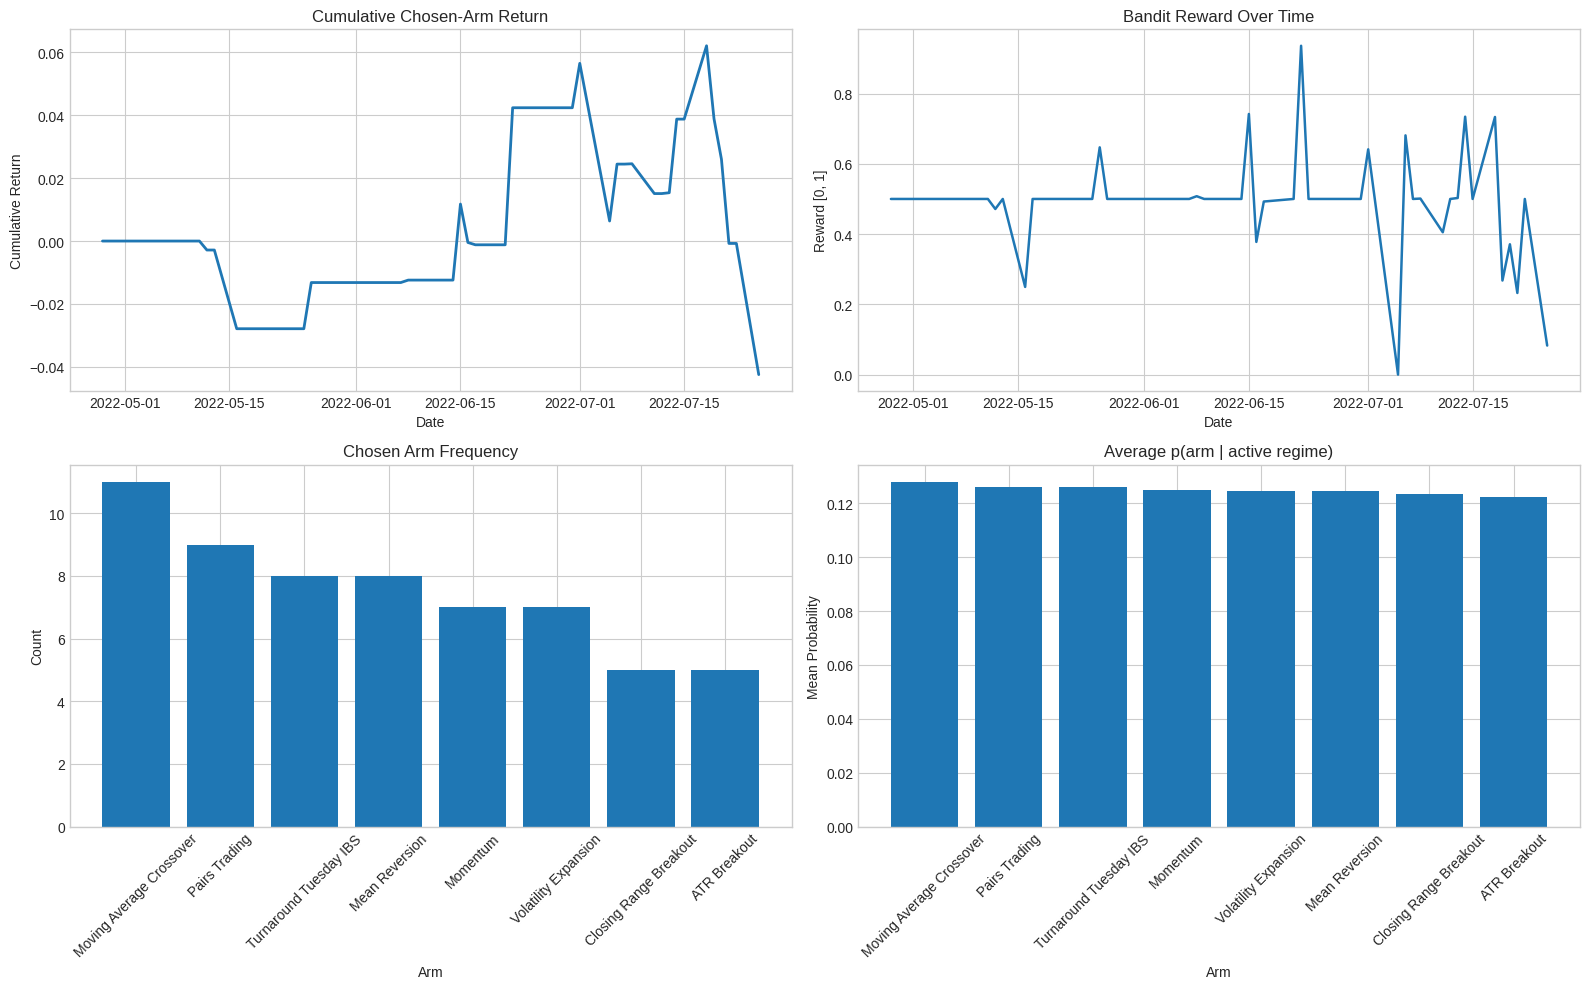

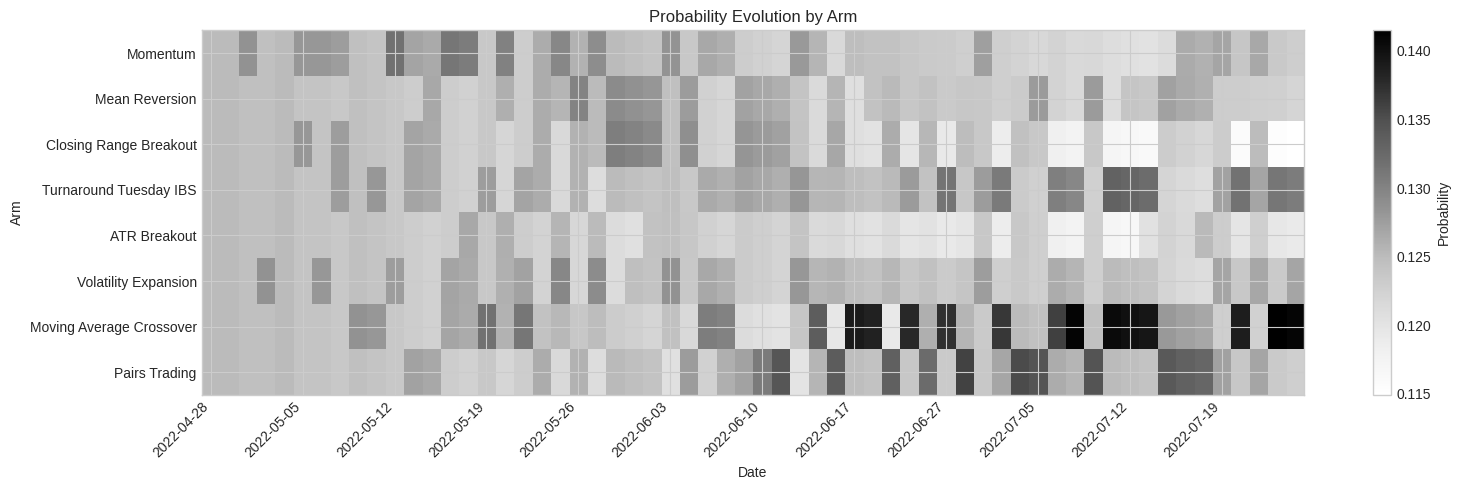


Demo completed successfully.


In [34]:
# Cell 4 - robust demo test + improved visualizations

import matplotlib.pyplot as plt

# Keep arm builders aligned with available strategy helper functions.
ARM_BUILDERS = {
    "Momentum": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Momentum",
        strategy_fn=lambda df_, ticker_: time_series_momentum_strategy(
            df_,
            ticker_,
            start_date=start_date,
            end_date=end_date,
            price_col="close",
            lookback=20,
            threshold=0.0,
            allow_short=True,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Mean Reversion": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Mean Reversion",
        strategy_fn=lambda df_, ticker_: mean_reversion_strategy(
            df_,
            ticker_,
            price_col="close",
            lookback=20,
            entry_z=2.0,
            exit_z=0.5,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Closing Range Breakout": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Closing Range Breakout",
        strategy_fn=lambda df_, ticker_: closing_range_breakout(
            df_,
            ticker_,
            price_col="close",
            lookback=20,
            upper_th=0.8,
            lower_th=0.2,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Turnaround Tuesday IBS": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Turnaround Tuesday IBS",
        strategy_fn=lambda df_, ticker_: turnaround_tuesday_ibs(
            df_,
            ticker_,
            ibs_threshold=0.2,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "ATR Breakout": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="ATR Breakout",
        strategy_fn=lambda df_, ticker_: atr_breakout(
            df_,
            ticker_,
            high_col="high",
            low_col="low",
            close_col="close",
            atr_lookback=14,
            multiplier=2.0,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Volatility Expansion": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Volatility Expansion",
        strategy_fn=lambda df_, ticker_: volatility_expansion(
            df_,
            ticker_,
            close_col="close",
            vol_lookback=20,
            vol_multiplier=1.5,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Moving Average Crossover": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_single_stock_strategy_portfolio(
        data_frame=data_frame,
        strategy_name="Moving Average Crossover",
        strategy_fn=lambda df_, ticker_: moving_average_crossover(
            df_,
            ticker_,
            close_col="close",
            short_window=20,
            long_window=50,
            allow_short=True,
            start_date=start_date,
            end_date=end_date,
        ),
        tickers=tickers,
        vol_lookback=vol_lookback,
        start_date=start_date,
        end_date=end_date,
    ),
    "Pairs Trading": lambda data_frame, tickers, start_date=None, end_date=None, vol_lookback=20: build_pairs_trading_portfolio(
        data_frame=data_frame,
        tickers=tickers,
        start_date=start_date,
        end_date=end_date,
    ),
}

all_dates = df.index.sort_values().unique()
if len(all_dates) < 120:
    raise ValueError(f"Not enough rows in df to run demo. Need >=120, found {len(all_dates)}")

# Use a dynamic window while keeping enough warmup history for slower strategies.
start_idx = 80
end_idx = min(start_idx + 60, len(all_dates))
demo_dates = all_dates[start_idx:end_idx]

n = len(demo_dates)
if n == 0:
    raise ValueError("Demo date slice is empty. Check index bounds and df index.")

# Deterministic synthetic regime probabilities for testing.
rng = np.random.default_rng(42)
raw_probs = rng.dirichlet(alpha=[2.0, 2.0, 2.0], size=n)
regime_probabilities_demo = pd.DataFrame(
    {
        "p_trending": raw_probs[:, 0],
        "p_meanrev": raw_probs[:, 1],
        "p_highvol": raw_probs[:, 2],
    },
    index=demo_dates,
)

bandit_results_demo = run_regime_specific_exp3(
    data_frame=df.loc[demo_dates.min():demo_dates.max()],
    regime_probabilities=regime_probabilities_demo,
    tickers=tickers,
    arm_builders=ARM_BUILDERS,
    gamma=0.07,
    vol_lookback=20,
    reward_clip=0.05,
    seed=42,
    start_date=str(demo_dates.min().date()),
    end_date=str(demo_dates.max().date()),
)

history = bandit_results_demo["history"].copy()
final_probs = bandit_results_demo["final_arm_probabilities_by_regime"].copy()

print("Final p(arm | regime):")
display(final_probs)

print("\nBandit history (tail):")
display(history.tail(10))

# Build available probability columns robustly (works even if arm set changes).
prob_cols = [c for c in history.columns if c.startswith("p_")]

# Human-readable compact audit output.
for date, row in history.iterrows():
    print("=" * 100)
    print(f"DATE: {pd.Timestamp(date).date()} | REGIME: {row['regime']} | CHOSEN ARM: {row['chosen_arm']}")
    print(f"CHOSEN ARM RETURN: {row['chosen_arm_return']:.6f} | BANDIT REWARD: {row['bandit_reward']:.6f}")

    probs_info = []
    for col in prob_cols:
        arm_name = col[2:]
        probs_info.append(f"{arm_name}: {row[col]:.4f}")
    print(f"P(arm | regime={row['regime']}): {{{', '.join(probs_info)}}}")

# ---------- Improved Visualizations ----------
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("default")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Cumulative chosen-arm return
history["cum_chosen_arm_return"] = history["chosen_arm_return"].cumsum()
axes[0, 0].plot(history.index, history["cum_chosen_arm_return"], linewidth=2)
axes[0, 0].set_title("Cumulative Chosen-Arm Return")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Cumulative Return")

# 2) Bandit reward over time
axes[0, 1].plot(history.index, history["bandit_reward"], linewidth=1.8)
axes[0, 1].set_title("Bandit Reward Over Time")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Reward [0, 1]")

# 3) Arm selection frequency
arm_counts = history["chosen_arm"].value_counts().sort_values(ascending=False)
axes[1, 0].bar(arm_counts.index, arm_counts.values)
axes[1, 0].set_title("Chosen Arm Frequency")
axes[1, 0].set_xlabel("Arm")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4) Mean selection probability by arm
if prob_cols:
    mean_probs = history[prob_cols].mean().sort_values(ascending=False)
    axes[1, 1].bar([c[2:] for c in mean_probs.index], mean_probs.values)
    axes[1, 1].set_title("Average p(arm | active regime)")
    axes[1, 1].set_xlabel("Arm")
    axes[1, 1].set_ylabel("Mean Probability")
    axes[1, 1].tick_params(axis="x", rotation=45)
else:
    axes[1, 1].text(0.5, 0.5, "No probability columns found", ha="center", va="center")
    axes[1, 1].set_title("Average p(arm | active regime)")

plt.tight_layout()
plt.show()

# Optional: visualize probability evolution as a heatmap-style image.
if prob_cols:
    prob_matrix = history[prob_cols].T
    fig, ax = plt.subplots(figsize=(16, 5))
    im = ax.imshow(prob_matrix.values, aspect="auto")
    ax.set_yticks(range(len(prob_matrix.index)))
    ax.set_yticklabels([c[2:] for c in prob_matrix.index])
    step = max(1, len(history.index) // 12)
    xticks = list(range(0, len(history.index), step))
    ax.set_xticks(xticks)
    ax.set_xticklabels([pd.Timestamp(history.index[i]).date() for i in xticks], rotation=45, ha="right")
    ax.set_title("Probability Evolution by Arm")
    ax.set_xlabel("Date")
    ax.set_ylabel("Arm")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Probability")
    plt.tight_layout()
    plt.show()

print("\nDemo completed successfully.")